In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Statsmodels for time-series tests (all imports grouped together up-front)
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import VECM, select_order, select_coint_rank, coint_johansen
from statsmodels.tools.sm_exceptions import InfeasibleTestError

# ML imports (added for XGBoost / Random Forest / SHAP)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import shap

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

/Users/rr/Documents/Diajeng/citi/timexer/TimeXer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('.././dataset/forPaper/Kaohsiung_DCS002_All_10_Minutely.csv')

In [3]:
df.head()

,Date Time,DCS002 Real Output Power,DCS002 Real Irradiance,Simulated Output Power from DCS002 Real Irradiance,Simulated Power Generated,Simulated DC Inverter Input,Plane Of Array Irradiance,Transmitted Plane Of Array Irradiance,Module Temperature,DHI,...,Elevation Radiant,Azimuth Radiant,Angle Of Incidence Radiant,Hour Angle Radiant,Airmass Relative,Airmass Absolute,Latitude,Longitude,Time Zone,Altitude
0,2019-12-01 00:00:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,...,-1.515869,1.238594,0.0,-3.085705,0.0,0.0,22.72,120.35,Asia/Taipei,22
1,2019-12-01 00:10:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,...,-1.476853,1.392141,0.0,-3.042082,0.0,0.0,22.72,120.35,Asia/Taipei,22
2,2019-12-01 00:20:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,...,-1.437030,1.459931,0.0,-2.998460,0.0,0.0,22.72,120.35,Asia/Taipei,22
3,2019-12-01 00:30:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,...,-1.396960,1.500401,0.0,-2.954838,0.0,0.0,22.72,120.35,Asia/Taipei,22
4,2019-12-01 00:40:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,0,...,-1.356790,1.528855,0.0,-2.911216,0.0,0.0,22.72,120.35,Asia/Taipei,22


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57168 entries, 0 to 57167
Data columns (total 62 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Date Time                                           57168 non-null  object 
 1   DCS002 Real Output Power                            57168 non-null  float64
 2   DCS002 Real Irradiance                              57168 non-null  float64
 3   Simulated Output Power from DCS002 Real Irradiance  57168 non-null  float64
 4   Simulated Power Generated                           57168 non-null  float64
 5   Simulated DC Inverter Input                         57168 non-null  float64
 6   Plane Of Array Irradiance                           57168 non-null  float64
 7   Transmitted Plane Of Array Irradiance               57168 non-null  float64
 8   Module Temperature                                  57168 non-null  float64


In [5]:
df.shape[0], df.shape[1]

(57168, 62)

In [6]:
df.index = pd.to_datetime(df['Date Time'], format='ISO8601')
df.drop(columns=['Date Time'], inplace=True)

In [7]:
df.head()

,DCS002 Real Output Power,DCS002 Real Irradiance,Simulated Output Power from DCS002 Real Irradiance,Simulated Power Generated,Simulated DC Inverter Input,Plane Of Array Irradiance,Transmitted Plane Of Array Irradiance,Module Temperature,DHI,DNI,...,Elevation Radiant,Azimuth Radiant,Angle Of Incidence Radiant,Hour Angle Radiant,Airmass Relative,Airmass Absolute,Latitude,Longitude,Time Zone,Altitude
Date Time,,,,,,,,,,,,,,,,,,,,,
2019-12-01 00:00:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,0,...,-1.515869,1.238594,0.0,-3.085705,0.0,0.0,22.72,120.35,Asia/Taipei,22
2019-12-01 00:10:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,0,...,-1.476853,1.392141,0.0,-3.042082,0.0,0.0,22.72,120.35,Asia/Taipei,22
2019-12-01 00:20:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,0,...,-1.437030,1.459931,0.0,-2.998460,0.0,0.0,22.72,120.35,Asia/Taipei,22
2019-12-01 00:30:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,0,...,-1.396960,1.500401,0.0,-2.954838,0.0,0.0,22.72,120.35,Asia/Taipei,22
2019-12-01 00:40:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,0,0,...,-1.356790,1.528855,0.0,-2.911216,0.0,0.0,22.72,120.35,Asia/Taipei,22


In [8]:
df.tail()

,DCS002 Real Output Power,DCS002 Real Irradiance,Simulated Output Power from DCS002 Real Irradiance,Simulated Power Generated,Simulated DC Inverter Input,Plane Of Array Irradiance,Transmitted Plane Of Array Irradiance,Module Temperature,DHI,DNI,...,Elevation Radiant,Azimuth Radiant,Angle Of Incidence Radiant,Hour Angle Radiant,Airmass Relative,Airmass Absolute,Latitude,Longitude,Time Zone,Altitude
Date Time,,,,,,,,,,,,,,,,,,,,,
2020-12-31 23:10:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.7,0,0,...,-1.362312,4.642496,0.0,2.915321,0.0,0.0,22.72,120.35,Asia/Taipei,22
2020-12-31 23:20:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.7,0,0,...,-1.402450,4.644914,0.0,2.958939,0.0,0.0,22.72,120.35,Asia/Taipei,22
2020-12-31 23:30:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.7,0,0,...,-1.442591,4.643472,0.0,3.002558,0.0,0.0,22.72,120.35,Asia/Taipei,22
2020-12-31 23:40:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.7,0,0,...,-1.482716,4.632941,0.0,3.046177,0.0,0.0,22.72,120.35,Asia/Taipei,22
2020-12-31 23:50:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.7,0,0,...,-1.522763,4.590637,0.0,3.089796,0.0,0.0,22.72,120.35,Asia/Taipei,22


In [9]:
print(df.index.freq)
print(df.index[:5])

None
DatetimeIndex(['2019-12-01 00:00:00+08:00', '2019-12-01 00:10:00+08:00',
               '2019-12-01 00:20:00+08:00', '2019-12-01 00:30:00+08:00',
               '2019-12-01 00:40:00+08:00'],
              dtype='datetime64[ns, UTC+08:00]', name='Date Time', freq=None)


In [10]:
df = df.sort_index()
df = df.select_dtypes(include='number').resample('10min').mean()
print(df.index.freq)

<10 * Minutes>


In [11]:
df_2019 = df.loc['2019-12-01 00:00:00+08:00':'2019-12-31 23:50:00+08:00'].copy()
df_2020 = df.loc['2020-01-01 00:00:00+08:00':'2020-12-31 23:50:00+08:00'].copy()

df_2019.head(), df_2020.head()

(                           DCS002 Real Output Power  DCS002 Real Irradiance  \
 Date Time                                                                     
 2019-12-01 00:00:00+08:00                       0.0                     0.0   
 2019-12-01 00:10:00+08:00                       0.0                     0.0   
 2019-12-01 00:20:00+08:00                       0.0                     0.0   
 2019-12-01 00:30:00+08:00                       0.0                     0.0   
 2019-12-01 00:40:00+08:00                       0.0                     0.0   
 
                            Simulated Output Power from DCS002 Real Irradiance  \
 Date Time                                                                       
 2019-12-01 00:00:00+08:00                                                0.0    
 2019-12-01 00:10:00+08:00                                                0.0    
 2019-12-01 00:20:00+08:00                                                0.0    
 2019-12-01 00:30:00+08:00  

# Focus: 2019

In [12]:
df_2019.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4464 entries, 2019-12-01 00:00:00+08:00 to 2019-12-31 23:50:00+08:00
Freq: 10min
Data columns (total 57 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   DCS002 Real Output Power                            4464 non-null   float64
 1   DCS002 Real Irradiance                              4464 non-null   float64
 2   Simulated Output Power from DCS002 Real Irradiance  4464 non-null   float64
 3   Simulated Power Generated                           4464 non-null   float64
 4   Simulated DC Inverter Input                         4464 non-null   float64
 5   Plane Of Array Irradiance                           4464 non-null   float64
 6   Transmitted Plane Of Array Irradiance               4464 non-null   float64
 7   Module Temperature                                  4464 non-null   float64
 8   DHI               

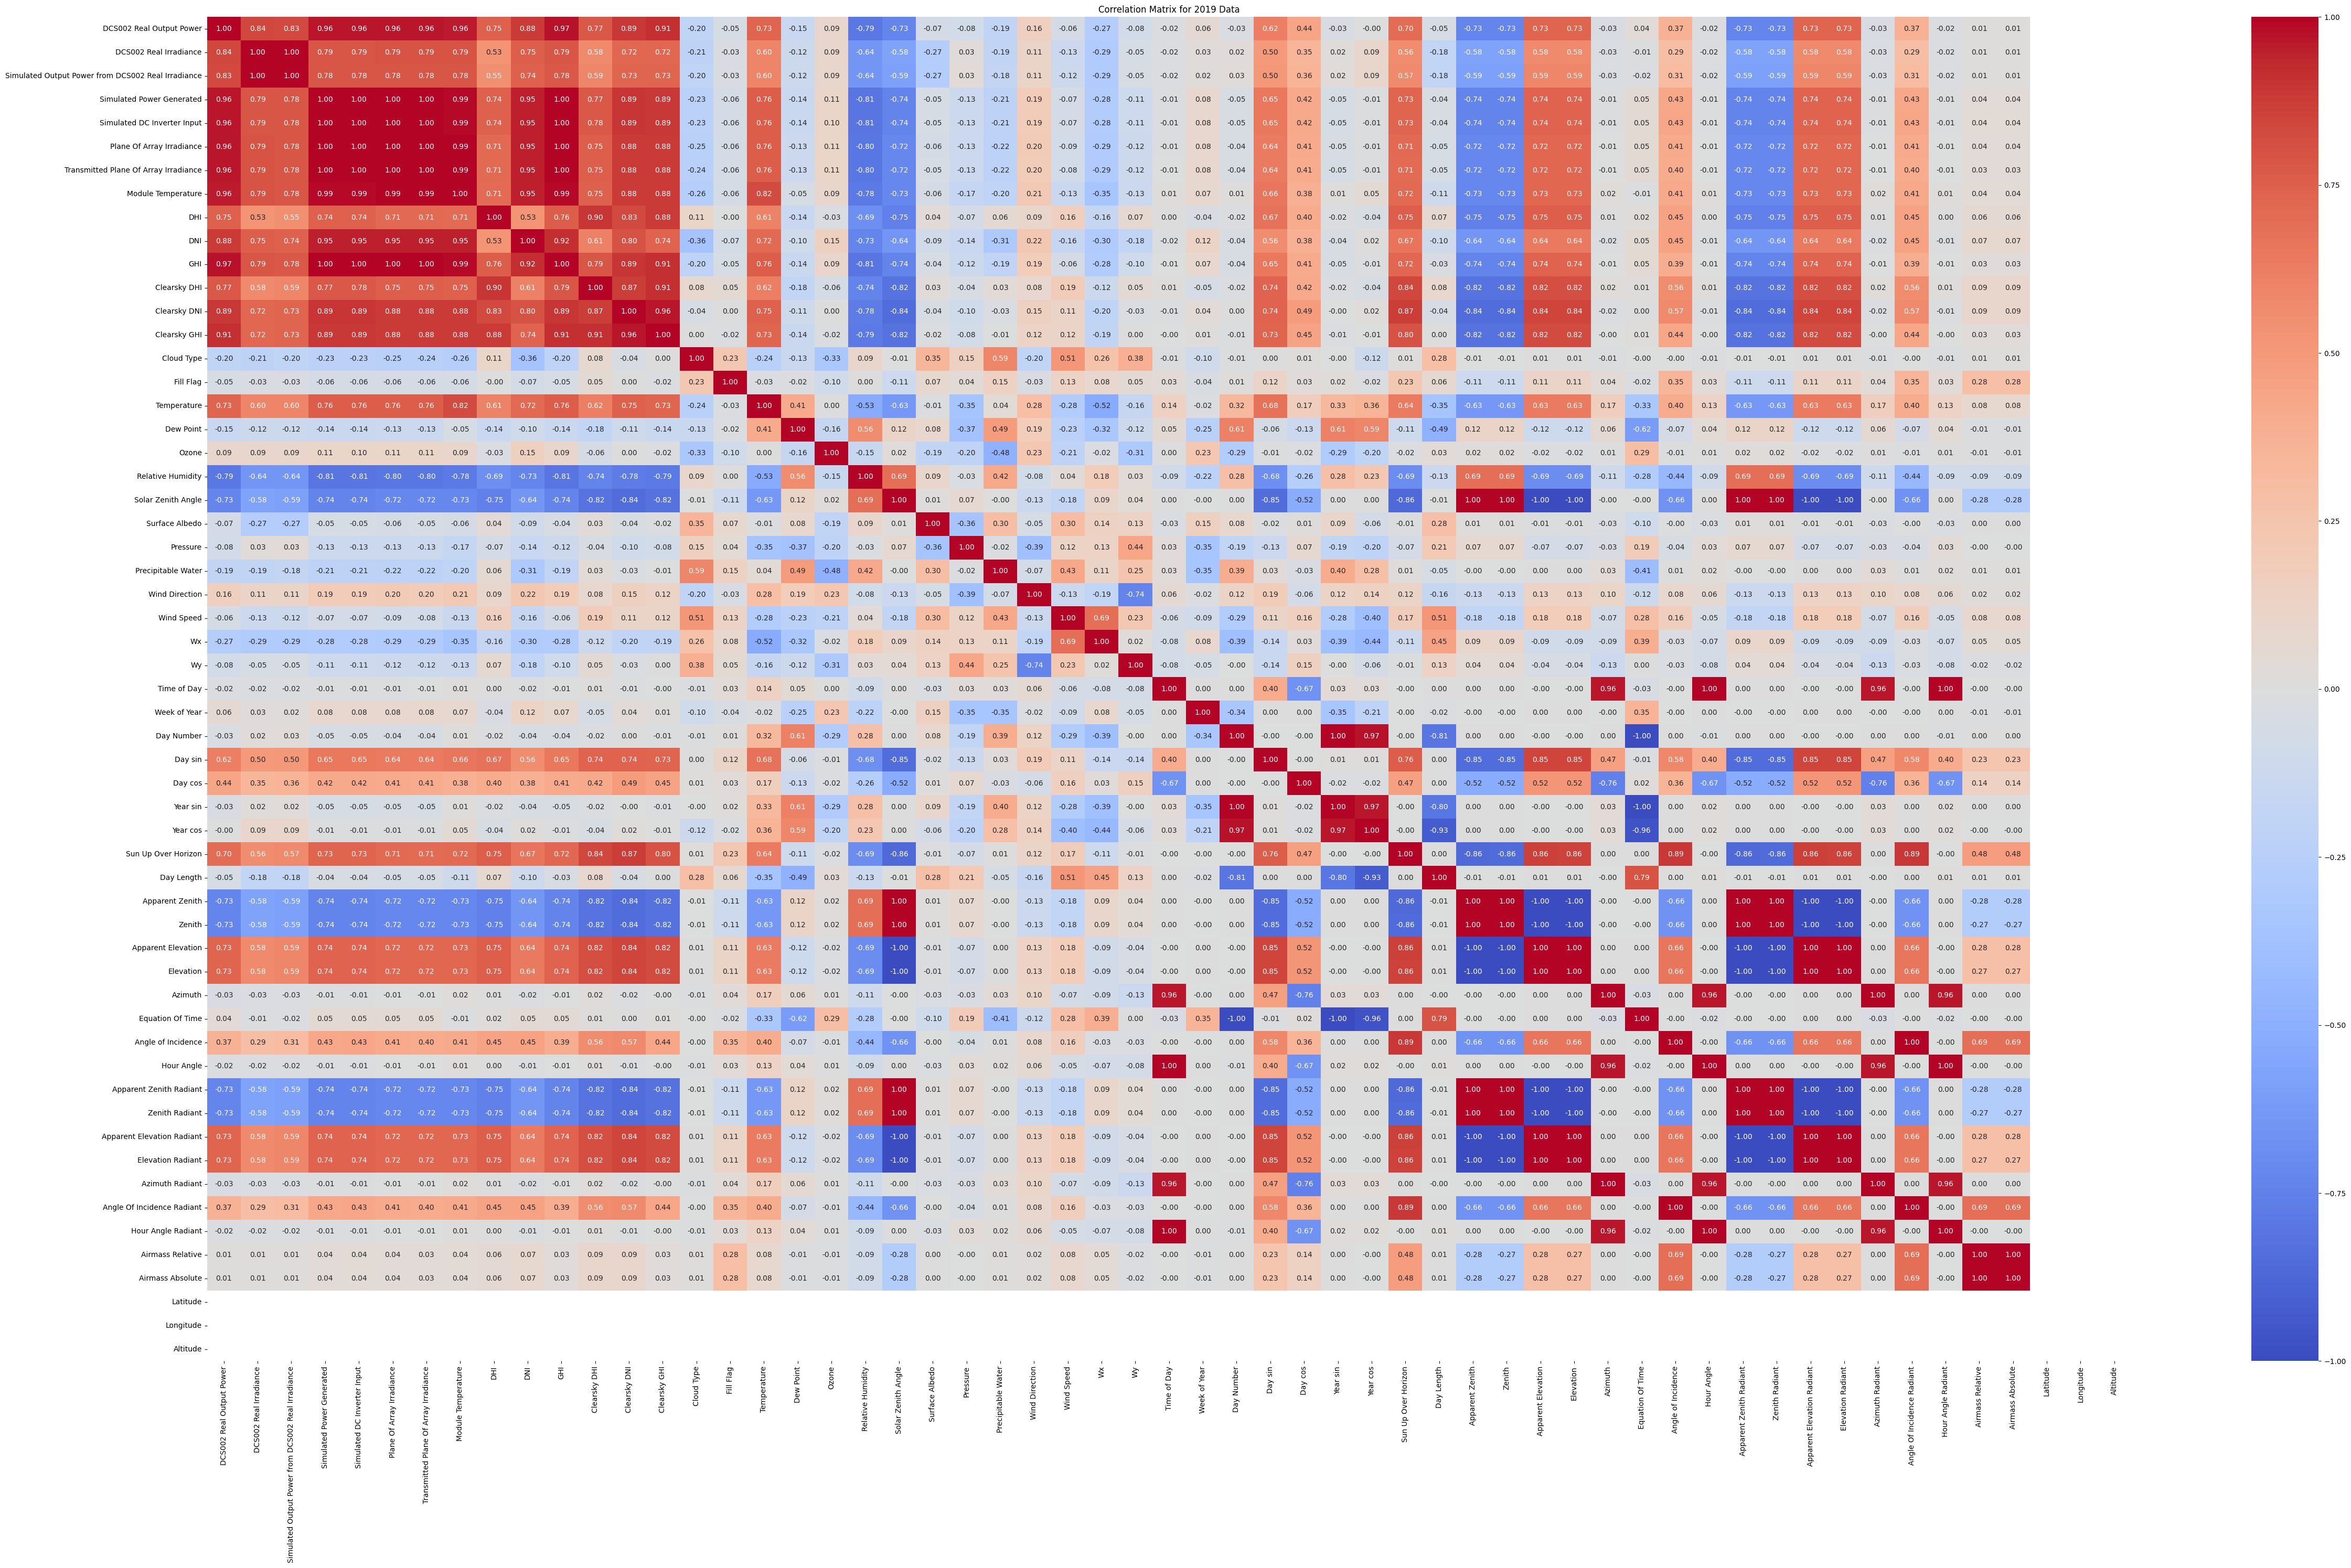

In [13]:
# Correlation matrix for 2019
corr_matrix = df_2019.select_dtypes(include='number').corr()

plt.figure(figsize=(50, 30))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for 2019 Data')
plt.tight_layout()
plt.show()

In [14]:
# Collect strongly correlated feature pairs from the 2019 numeric correlation matrix.
# Threshold: |corr| in [0.6, 0.99] (exclude trivial perfect correlation)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_pairs = (
    upper_tri
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'correlation'})
)

mask = (corr_pairs['correlation'].abs() >= 0.6) & (corr_pairs['correlation'].abs() <= 0.99)
colls = sorted(set(corr_pairs.loc[mask, 'var1']).union(corr_pairs.loc[mask, 'var2']))

print(f"Strongly correlated feature set ({len(colls)} columns):")
colls

Strongly correlated feature set (47 columns):


['Airmass Absolute',
 'Airmass Relative',
 'Angle Of Incidence Radiant',
 'Angle of Incidence',
 'Apparent Elevation',
 'Apparent Elevation Radiant',
 'Apparent Zenith',
 'Apparent Zenith Radiant',
 'Azimuth',
 'Azimuth Radiant',
 'Clearsky DHI',
 'Clearsky DNI',
 'Clearsky GHI',
 'DCS002 Real Irradiance',
 'DCS002 Real Output Power',
 'DHI',
 'DNI',
 'Day Length',
 'Day Number',
 'Day cos',
 'Day sin',
 'Dew Point',
 'Elevation',
 'Elevation Radiant',
 'Equation Of Time',
 'GHI',
 'Hour Angle',
 'Hour Angle Radiant',
 'Module Temperature',
 'Plane Of Array Irradiance',
 'Relative Humidity',
 'Simulated DC Inverter Input',
 'Simulated Output Power from DCS002 Real Irradiance',
 'Simulated Power Generated',
 'Solar Zenith Angle',
 'Sun Up Over Horizon',
 'Temperature',
 'Time of Day',
 'Transmitted Plane Of Array Irradiance',
 'Wind Direction',
 'Wind Speed',
 'Wx',
 'Wy',
 'Year cos',
 'Year sin',
 'Zenith',
 'Zenith Radiant']

In [15]:
# Pearson correlation between strongly correlated pairs
from itertools import combinations
from scipy.stats import pearsonr

for col1, col2 in combinations(colls, 2):
    series1 = df_2019[col1].dropna()
    series2 = df_2019[col2].dropna()

    # Align indices
    common_index = series1.index.intersection(series2.index)
    series1 = series1.loc[common_index]
    series2 = series2.loc[common_index]

    if len(series1) < 3 or series1.nunique() < 2 or series2.nunique() < 2:
        print(f"Pearson '{col1}' vs '{col2}': skipped (insufficient variation)")
        continue

    corr_coef, p_value = pearsonr(series1, series2)
    print(f"Pearson correlation between '{col1}' and '{col2}': {corr_coef:.4f}, p-value: {p_value:.4f}")

Pearson correlation between 'Airmass Absolute' and 'Airmass Relative': 1.0000, p-value: 0.0000
Pearson correlation between 'Airmass Absolute' and 'Angle Of Incidence Radiant': 0.6938, p-value: 0.0000
Pearson correlation between 'Airmass Absolute' and 'Angle of Incidence': 0.6938, p-value: 0.0000
Pearson correlation between 'Airmass Absolute' and 'Apparent Elevation': 0.2760, p-value: 0.0000
Pearson correlation between 'Airmass Absolute' and 'Apparent Elevation Radiant': 0.2760, p-value: 0.0000
Pearson correlation between 'Airmass Absolute' and 'Apparent Zenith': -0.2760, p-value: 0.0000
Pearson correlation between 'Airmass Absolute' and 'Apparent Zenith Radiant': -0.2760, p-value: 0.0000
Pearson correlation between 'Airmass Absolute' and 'Azimuth': 0.0012, p-value: 0.9350
Pearson correlation between 'Airmass Absolute' and 'Azimuth Radiant': 0.0012, p-value: 0.9350
Pearson correlation between 'Airmass Absolute' and 'Clearsky DHI': 0.0915, p-value: 0.0000
Pearson correlation between 'Air

In [16]:
# Stationarity (ADF) test
for col in colls:
    series = df_2019[col].dropna()
    print(f'ADF test for column: {col}')

    if series.nunique() < 2:
        print('=> Skipped: series is constant\n')
        continue

    try:
        result = adfuller(series)
    except Exception as e:
        print(f'=> Skipped: {e}\n')
        continue

    adf_stat = result[0]
    p_value = result[1]
    crit_values = result[4]

    print(f'ADF Statistic: {adf_stat:.4f}')
    print(f'p-value:       {p_value:.4f}')
    print('Critical Values:')
    for key, value in crit_values.items():
        print(f'   {key}: {value:.4f}')

    if p_value < 0.05:
        print('=> Stationary (reject H0)\n')
    else:
        print('=> Non-stationary (fail to reject H0)\n')

ADF test for column: Airmass Absolute
ADF Statistic: -25.3246
p-value:       0.0000
Critical Values:
   1%: -3.4318
   5%: -2.8622
   10%: -2.5671
=> Stationary (reject H0)

ADF test for column: Airmass Relative
ADF Statistic: -25.3246
p-value:       0.0000
Critical Values:
   1%: -3.4318
   5%: -2.8622
   10%: -2.5671
=> Stationary (reject H0)

ADF test for column: Angle Of Incidence Radiant
ADF Statistic: -12.4695
p-value:       0.0000
Critical Values:
   1%: -3.4318
   5%: -2.8622
   10%: -2.5671
=> Stationary (reject H0)

ADF test for column: Angle of Incidence
ADF Statistic: -12.4695
p-value:       0.0000
Critical Values:
   1%: -3.4318
   5%: -2.8622
   10%: -2.5671
=> Stationary (reject H0)

ADF test for column: Apparent Elevation
ADF Statistic: -18.2289
p-value:       0.0000
Critical Values:
   1%: -3.4318
   5%: -2.8622
   10%: -2.5671
=> Stationary (reject H0)

ADF test for column: Apparent Elevation Radiant
ADF Statistic: -18.2289
p-value:       0.0000
Critical Values:
   1%

In [17]:
# Granger causality: does each column Granger-cause GHI?
# Fix: maxlag=144 was far too large for stable chi-square tests and produces
# numerical issues. We use a sensible default (maxlag=24 -> 4 hours at 10-min frequency).
daily_data = df_2019.select_dtypes(include='number').resample('10min').mean()

MAXLAG = 24
TARGET = 'GHI'
output_file = "./granger_causality_results.txt"

if TARGET not in daily_data.columns:
    raise KeyError(f"Target column '{TARGET}' not found in daily_data")

with open(output_file, "w") as file:
    for col1 in colls:
        if col1 == TARGET:
            continue

        file.write(f'Granger Causality: does "{col1}" cause "{TARGET}"?\n')

        # grangercausalitytests expects columns in order [target, predictor]
        data_for_test = daily_data[[TARGET, col1]].dropna()

        if len(data_for_test) < MAXLAG * 3:
            file.write("Skipped: insufficient observations.\n\n")
            continue

        try:
            test_result = grangercausalitytests(data_for_test, maxlag=MAXLAG, verbose=False)

            significant_lags = []
            for lag in range(1, MAXLAG + 1):
                p_value = test_result[lag][0]['ssr_chi2test'][1]
                file.write(f'Lag {lag}: p-value = {p_value:.4f}\n')
                if p_value < 0.05:
                    significant_lags.append(lag)

            if significant_lags:
                file.write(f"Conclusion: evidence that '{col1}' Granger-causes '{TARGET}' at lags {significant_lags}.\n")
            else:
                file.write(f"Conclusion: no evidence that '{col1}' Granger-causes '{TARGET}'.\n")

        except InfeasibleTestError:
            file.write(f"Conclusion: test infeasible — '{col1}' and '{TARGET}' have perfect correlation or singular covariance.\n")
        except Exception as e:
            file.write(f"Conclusion: error — {e}\n")

        file.write("\n")

print(f"Results saved to {output_file}")

Results saved to ./granger_causality_results.txt


In [18]:
# VECM fit — fixed version
#
# The original cell failed with:
#   LinAlgError: 27-th leading minor of the array is not positive definite
# because the covariance matrix was singular. Fixes applied:
#   1) Drop near-perfectly collinear columns (|corr| > 0.999), not only == 1.0
#      (floating-point equality rarely matches exactly).
#   2) Drop zero-variance columns.
#   3) Use a small, safe maxlag.
#   4) Guard against a zero cointegration rank (VECM requires rank >= 1).

# Step 1: Remove near-perfectly collinear columns (|corr| > 0.999)
corr_sub = daily_data[colls].corr().abs()
upper = corr_sub.where(np.triu(np.ones(corr_sub.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if (upper[col] > 0.999).any()]
print(f"Dropping near-perfectly collinear columns: {to_drop}")

colls_clean = [col for col in colls if col not in to_drop]

# Step 2: Drop zero-variance columns (would make the covariance singular)
data_vecm = daily_data[colls_clean].dropna()
zero_var = [c for c in data_vecm.columns if data_vecm[c].nunique() < 2]
if zero_var:
    print(f"Dropping zero-variance columns: {zero_var}")
    data_vecm = data_vecm.drop(columns=zero_var)
    colls_clean = [c for c in colls_clean if c not in zero_var]

print(f"Remaining columns ({len(colls_clean)}): {colls_clean}")

# Step 3: Safe maxlags (VECM rule of thumb: much less than n_obs / n_vars)
n_obs, n_vars = data_vecm.shape
safe_maxlags = max(1, min(12, n_obs // (5 * max(n_vars, 1))))
print(f"n_obs={n_obs}, n_vars={n_vars}, safe_maxlags={safe_maxlags}")

# Step 4: Select optimal lag (AIC)
order_results = select_order(data_vecm, maxlags=safe_maxlags, deterministic="co")
optimal_lag = max(1, int(order_results.aic or 1))
print("Optimal lag (AIC):", optimal_lag)

# Step 5: Johansen cointegration test
johansen_test = coint_johansen(data_vecm, det_order=0, k_ar_diff=optimal_lag)
print("Johansen Eigenvalues:", johansen_test.eig)
print("Trace Statistics:   ", johansen_test.lr1)
print("Critical Values (90%, 95%, 99%):\n", johansen_test.cvt)

# Step 6: Fit VECM
coint_rank = int(np.sum(johansen_test.lr1 > johansen_test.cvt[:, 1]))  # 95% threshold
coint_rank = max(1, coint_rank)  # VECM needs rank >= 1
print(f"Cointegration rank used: {coint_rank}")

vecm_model = VECM(data_vecm, k_ar_diff=optimal_lag, coint_rank=coint_rank, deterministic="co")
vecm_res = vecm_model.fit()
print(vecm_res.summary())

Dropping near-perfectly collinear columns: ['Airmass Relative', 'Angle of Incidence', 'Apparent Elevation Radiant', 'Apparent Zenith', 'Apparent Zenith Radiant', 'Azimuth Radiant', 'Elevation', 'Elevation Radiant', 'Hour Angle Radiant', 'Simulated Power Generated', 'Solar Zenith Angle', 'Time of Day', 'Transmitted Plane Of Array Irradiance', 'Year sin', 'Zenith', 'Zenith Radiant']
Remaining columns (31): ['Airmass Absolute', 'Angle Of Incidence Radiant', 'Apparent Elevation', 'Azimuth', 'Clearsky DHI', 'Clearsky DNI', 'Clearsky GHI', 'DCS002 Real Irradiance', 'DCS002 Real Output Power', 'DHI', 'DNI', 'Day Length', 'Day Number', 'Day cos', 'Day sin', 'Dew Point', 'Equation Of Time', 'GHI', 'Hour Angle', 'Module Temperature', 'Plane Of Array Irradiance', 'Relative Humidity', 'Simulated DC Inverter Input', 'Simulated Output Power from DCS002 Real Irradiance', 'Sun Up Over Horizon', 'Temperature', 'Wind Direction', 'Wind Speed', 'Wx', 'Wy', 'Year cos']
n_obs=4464, n_vars=31, safe_maxlags=1

In [19]:
# Pairwise Engle-Granger cointegration test
for i in range(len(colls)):
    for j in range(i + 1, len(colls)):
        series1 = daily_data[colls[i]].dropna()
        series2 = daily_data[colls[j]].dropna()

        common_index = series1.index.intersection(series2.index)
        s1 = series1.loc[common_index]
        s2 = series2.loc[common_index]

        if len(s1) < 20 or s1.nunique() < 2 or s2.nunique() < 2:
            print(f"Cointegration '{colls[i]}' vs '{colls[j]}': skipped (insufficient data / constant series)")
            continue

        try:
            score, p_value, _ = coint(s1, s2)
            print(f"Cointegration test between '{colls[i]}' and '{colls[j]}': p-value = {p_value:.4f}")
        except Exception as e:
            print(f"Cointegration '{colls[i]}' vs '{colls[j]}': error — {e}")

Cointegration test between 'Airmass Absolute' and 'Airmass Relative': p-value = 0.0000
Cointegration test between 'Airmass Absolute' and 'Angle Of Incidence Radiant': p-value = 0.0000
Cointegration test between 'Airmass Absolute' and 'Angle of Incidence': p-value = 0.0000
Cointegration test between 'Airmass Absolute' and 'Apparent Elevation': p-value = 0.0000
Cointegration test between 'Airmass Absolute' and 'Apparent Elevation Radiant': p-value = 0.0000
Cointegration test between 'Airmass Absolute' and 'Apparent Zenith': p-value = 0.0000
Cointegration test between 'Airmass Absolute' and 'Apparent Zenith Radiant': p-value = 0.0000
Cointegration test between 'Airmass Absolute' and 'Azimuth': p-value = 0.0000
Cointegration test between 'Airmass Absolute' and 'Azimuth Radiant': p-value = 0.0000
Cointegration test between 'Airmass Absolute' and 'Clearsky DHI': p-value = 0.0000
Cointegration test between 'Airmass Absolute' and 'Clearsky DNI': p-value = 0.0000
Cointegration test between 'Air

# Machine Learning: Random Forest, XGBoost, Feature Importance, and SHAP

Goal: predict **GHI** from the other numeric features in the 2019 data, then
explain the models with classical feature importance and SHAP.

In [20]:
# Prepare modeling data.
# Target = GHI. Features = all other numeric columns in df_2019.
TARGET = 'GHI'

model_df = df_2019.select_dtypes(include='number').dropna().copy()

# Drop zero-variance columns — they carry no info and can break some models.
const_cols = [c for c in model_df.columns if model_df[c].nunique() < 2]
if const_cols:
    print(f"Dropping zero-variance columns: {const_cols}")
    model_df = model_df.drop(columns=const_cols)

assert TARGET in model_df.columns, f"'{TARGET}' missing from modeling frame"

y = model_df[TARGET]
X = model_df.drop(columns=[TARGET])

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Features: {list(X.columns)}")

Dropping zero-variance columns: ['Latitude', 'Longitude', 'Altitude']
X shape: (4464, 53), y shape: (4464,)
Features: ['DCS002 Real Output Power', 'DCS002 Real Irradiance', 'Simulated Output Power from DCS002 Real Irradiance', 'Simulated Power Generated', 'Simulated DC Inverter Input', 'Plane Of Array Irradiance', 'Transmitted Plane Of Array Irradiance', 'Module Temperature', 'DHI', 'DNI', 'Clearsky DHI', 'Clearsky DNI', 'Clearsky GHI', 'Cloud Type', 'Fill Flag', 'Temperature', 'Dew Point', 'Ozone', 'Relative Humidity', 'Solar Zenith Angle', 'Surface Albedo', 'Pressure', 'Precipitable Water', 'Wind Direction', 'Wind Speed', 'Wx', 'Wy', 'Time of Day', 'Week of Year', 'Day Number', 'Day sin', 'Day cos', 'Year sin', 'Year cos', 'Sun Up Over Horizon', 'Day Length', 'Apparent Zenith', 'Zenith', 'Apparent Elevation', 'Elevation', 'Azimuth', 'Equation Of Time', 'Angle of Incidence', 'Hour Angle', 'Apparent Zenith Radiant', 'Zenith Radiant', 'Apparent Elevation Radiant', 'Elevation Radiant', '

In [21]:
# Time-aware split: the data is a time series, so keep the last 20% for testing
# instead of a random split (prevents look-ahead leakage).
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train period: {X_train.index.min()} -> {X_train.index.max()}")
print(f"Test period:  {X_test.index.min()} -> {X_test.index.max()}")

Train: (3571, 53), Test: (893, 53)
Train period: 2019-12-01 00:00:00+08:00 -> 2019-12-25 19:00:00+08:00
Test period:  2019-12-25 19:10:00+08:00 -> 2019-12-31 23:50:00+08:00


## Random Forest

In [22]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_metrics = {
    'RMSE': float(np.sqrt(mean_squared_error(y_test, rf_pred))),
    'MAE':  float(mean_absolute_error(y_test, rf_pred)),
    'R2':   float(r2_score(y_test, rf_pred)),
}
print("Random Forest test metrics:")
for k, v in rf_metrics.items():
    print(f"  {k}: {v:.4f}")

Random Forest test metrics:
  RMSE: 2.8757
  MAE: 1.0318
  R2: 0.9997


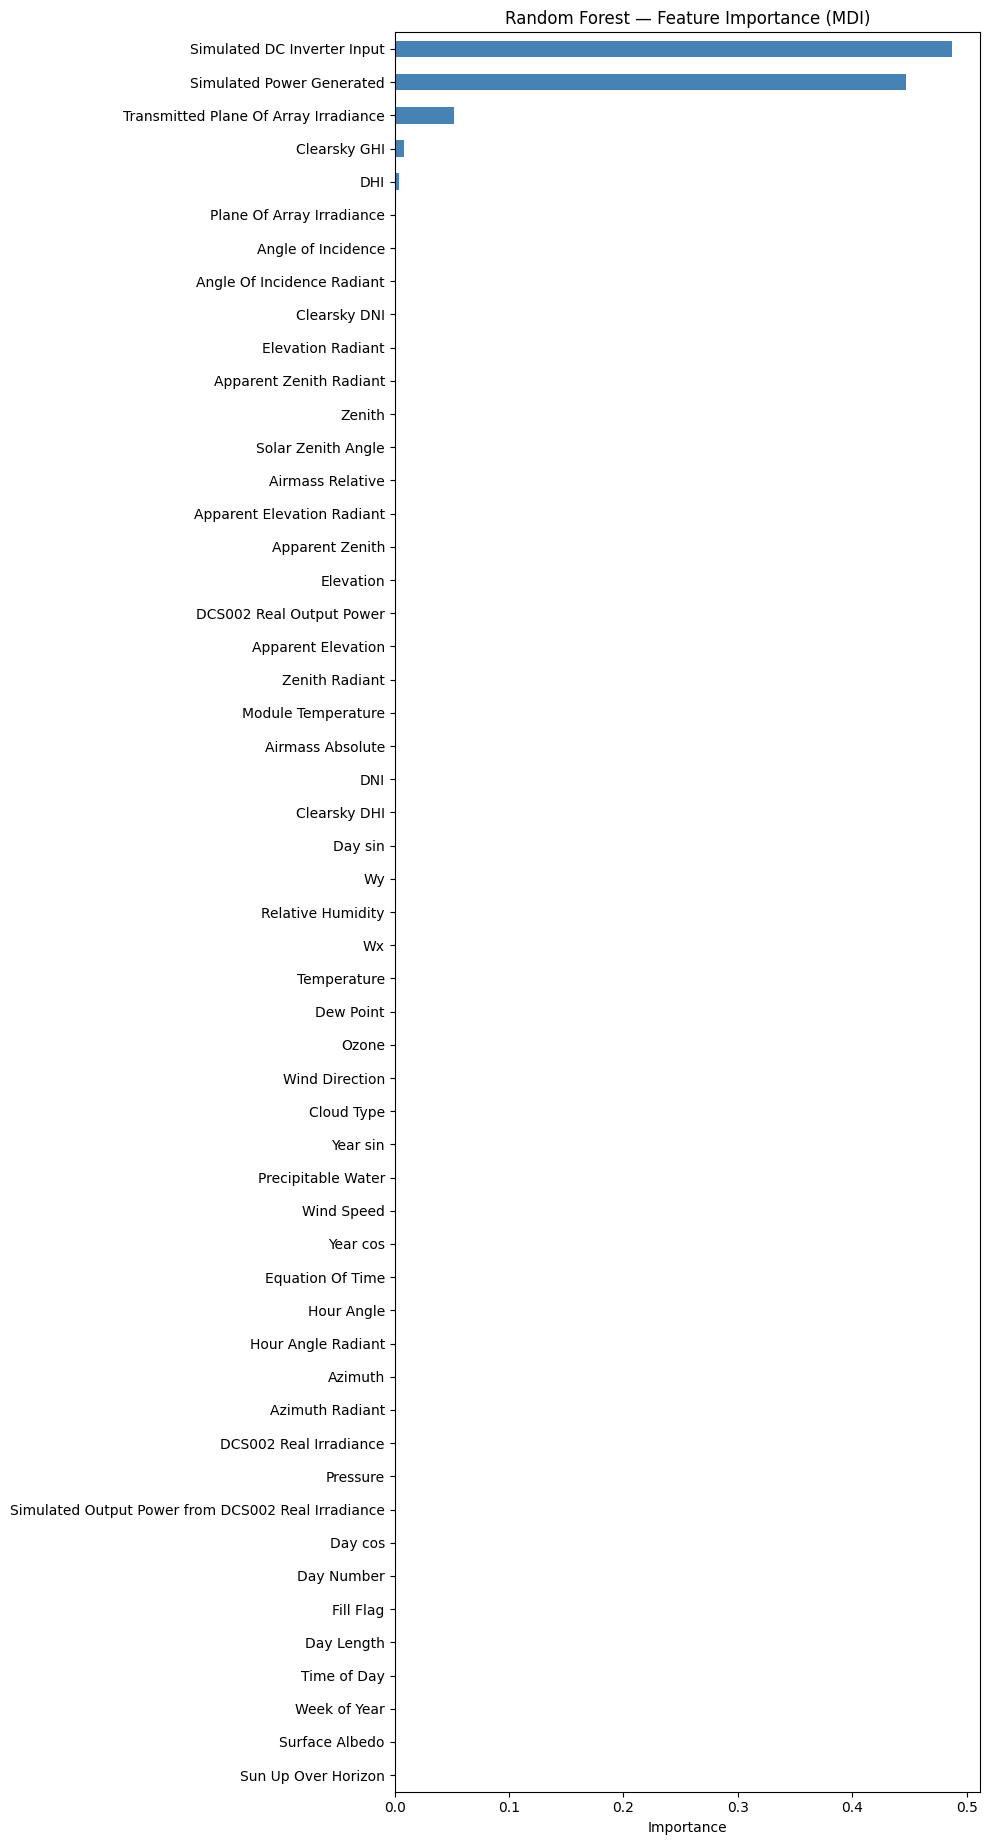

Simulated DC Inverter Input              0.487157
Simulated Power Generated                0.446940
Transmitted Plane Of Array Irradiance    0.052081
Clearsky GHI                             0.008646
DHI                                      0.004234
Plane Of Array Irradiance                0.000198
Angle of Incidence                       0.000123
Angle Of Incidence Radiant               0.000083
Clearsky DNI                             0.000049
Elevation Radiant                        0.000044
Apparent Zenith Radiant                  0.000042
Zenith                                   0.000035
Solar Zenith Angle                       0.000032
Airmass Relative                         0.000029
Apparent Elevation Radiant               0.000028
dtype: float64

In [23]:
# Random Forest feature importance (mean decrease in impurity)
rf_importance = (
    pd.Series(rf_model.feature_importances_, index=X.columns)
      .sort_values(ascending=True)
)

plt.figure(figsize=(10, max(4, 0.35 * len(rf_importance))))
rf_importance.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importance (MDI)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

rf_importance.sort_values(ascending=False).head(15)

## XGBoost

In [24]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_metrics = {
    'RMSE': float(np.sqrt(mean_squared_error(y_test, xgb_pred))),
    'MAE':  float(mean_absolute_error(y_test, xgb_pred)),
    'R2':   float(r2_score(y_test, xgb_pred)),
}
print("XGBoost test metrics:")
for k, v in xgb_metrics.items():
    print(f"  {k}: {v:.4f}")

XGBoost test metrics:
  RMSE: 2.5545
  MAE: 0.9889
  R2: 0.9997


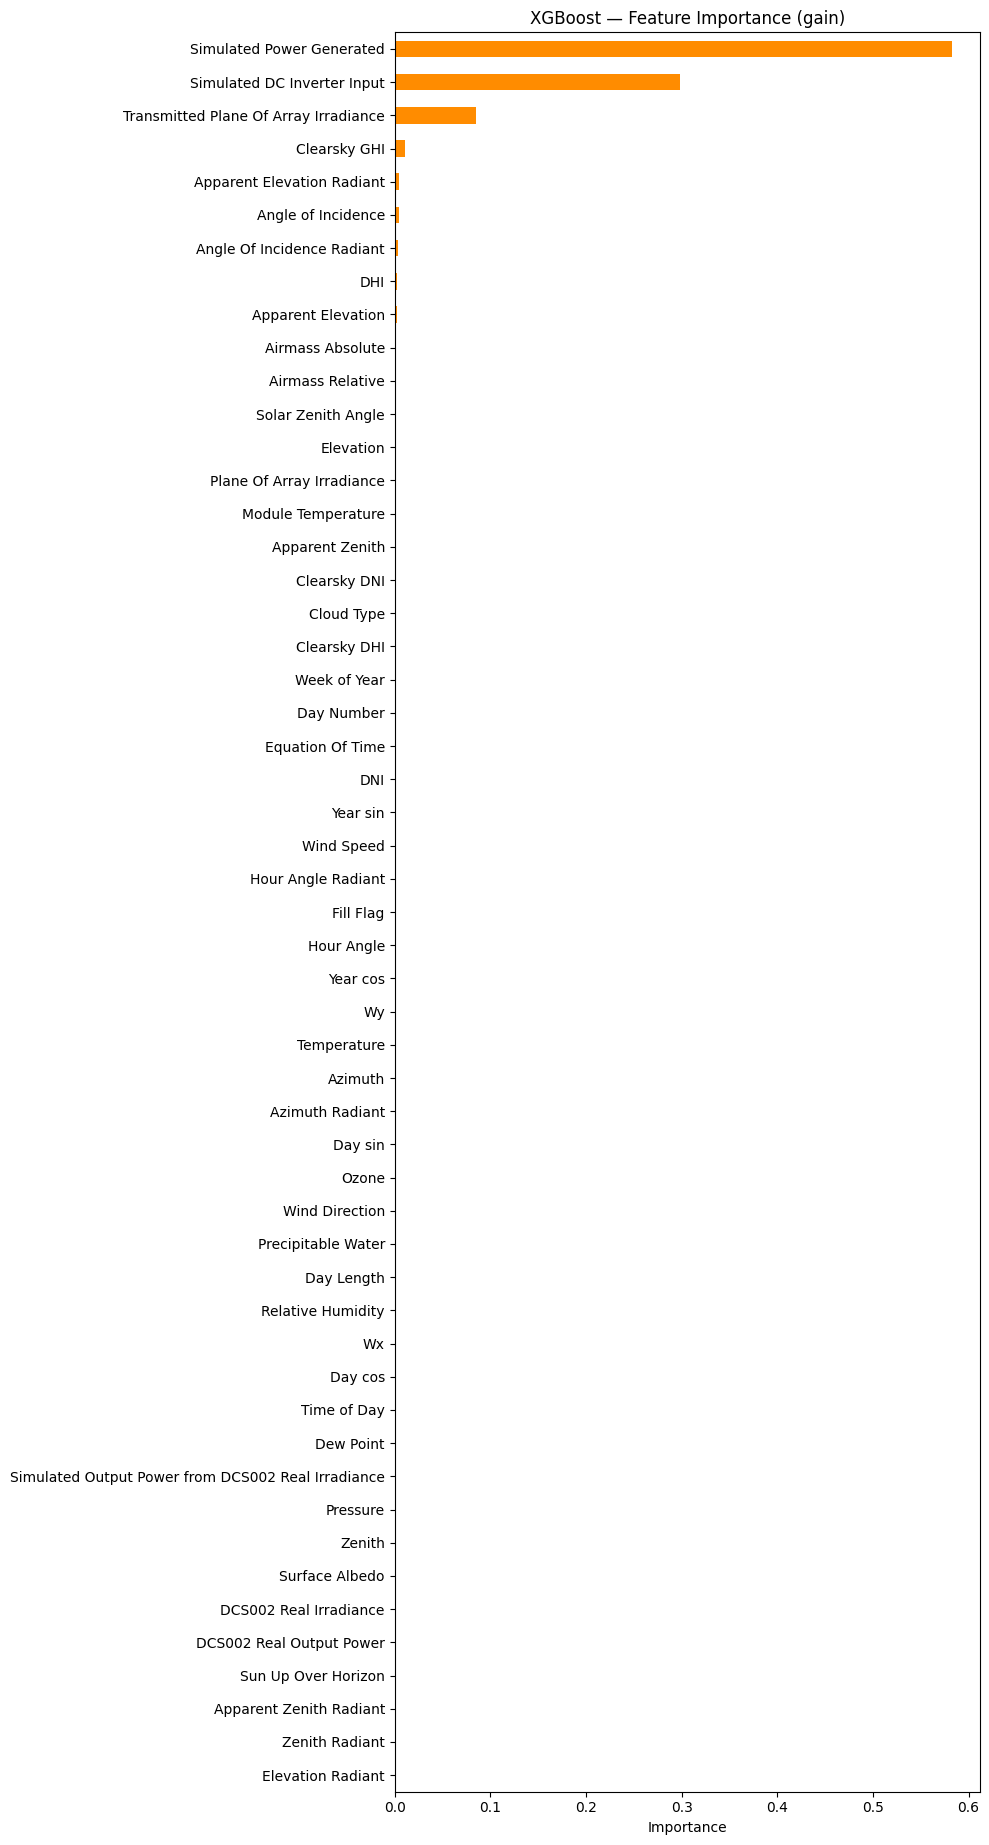

Simulated Power Generated                0.582807
Simulated DC Inverter Input              0.298376
Transmitted Plane Of Array Irradiance    0.085408
Clearsky GHI                             0.011113
Apparent Elevation Radiant               0.004893
Angle of Incidence                       0.004086
Angle Of Incidence Radiant               0.003803
DHI                                      0.002677
Apparent Elevation                       0.002017
Airmass Absolute                         0.001672
Airmass Relative                         0.001074
Solar Zenith Angle                       0.000797
Elevation                                0.000583
Plane Of Array Irradiance                0.000245
Module Temperature                       0.000158
dtype: float32

In [25]:
# XGBoost feature importance (gain)
xgb_importance = (
    pd.Series(xgb_model.feature_importances_, index=X.columns)
      .sort_values(ascending=True)
)

plt.figure(figsize=(10, max(4, 0.35 * len(xgb_importance))))
xgb_importance.plot(kind='barh', color='darkorange')
plt.title('XGBoost — Feature Importance (gain)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

xgb_importance.sort_values(ascending=False).head(15)

In [26]:
# Side-by-side metric comparison
metrics_df = pd.DataFrame({'RandomForest': rf_metrics, 'XGBoost': xgb_metrics}).T
metrics_df

,RMSE,MAE,R2
RandomForest,2.875683,1.031782,0.99967
XGBoost,2.554543,0.988884,0.99974


## SHAP explanations

SHAP values decompose each prediction into additive feature contributions, so
we can see not just *which* features matter but *how* they push predictions
up or down.

In [27]:
# Sample the test set for SHAP — the full test set can be slow for beeswarm plots.
SHAP_SAMPLE_SIZE = min(1000, len(X_test))
X_shap = X_test.sample(SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE).sort_index()
print(f"SHAP evaluation sample size: {len(X_shap)}")

SHAP evaluation sample size: 893


### SHAP for Random Forest

In [28]:
# TreeExplainer works for both Random Forest and XGBoost.
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_shap)

print("SHAP values shape:", np.shape(rf_shap_values))

SHAP values shape: (893, 53)


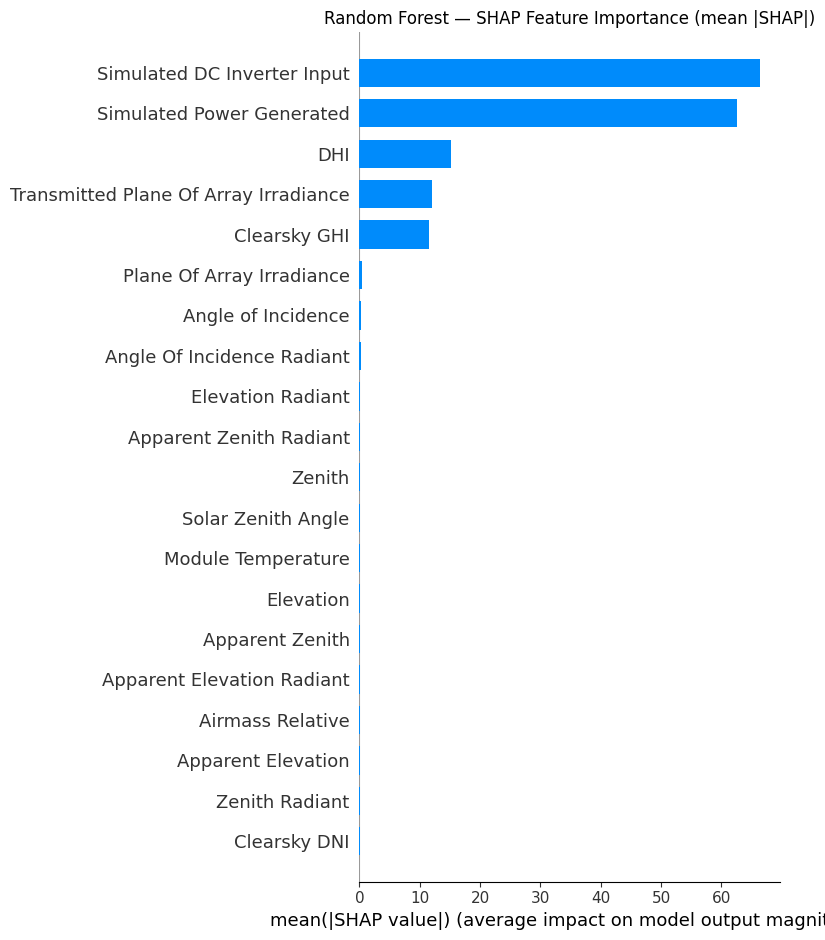

In [29]:
# Global importance (mean |SHAP|) — bar summary
shap.summary_plot(rf_shap_values, X_shap, plot_type='bar', show=False)
plt.title('Random Forest — SHAP Feature Importance (mean |SHAP|)')
plt.tight_layout()
plt.show()

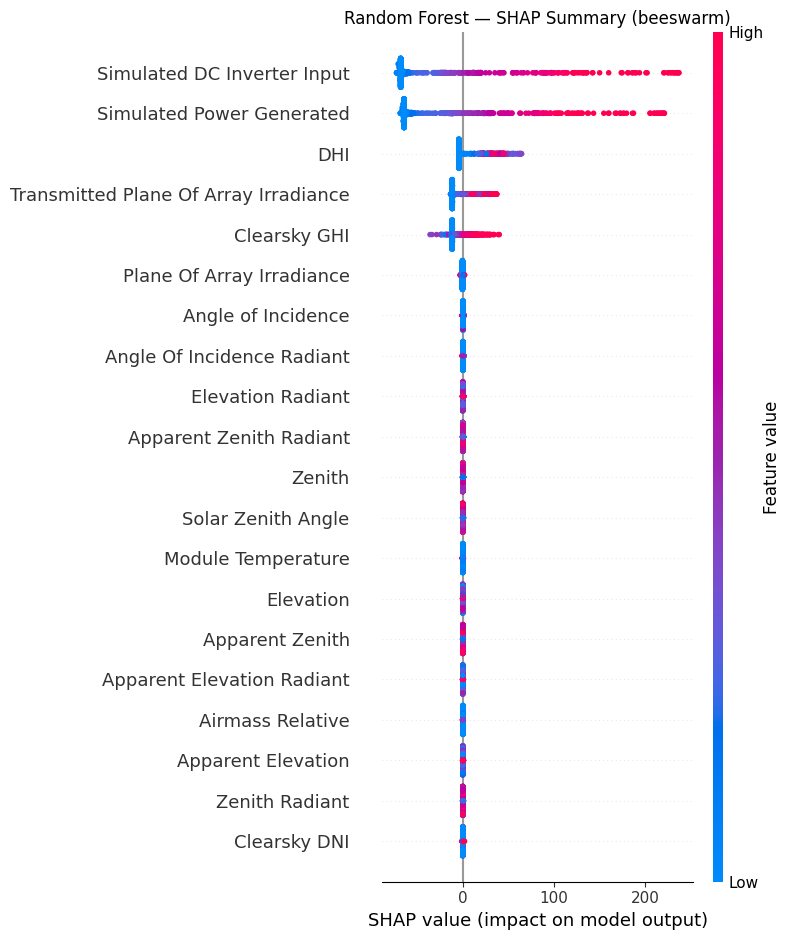

In [30]:
# Beeswarm: shows direction and magnitude of each feature's effect
shap.summary_plot(rf_shap_values, X_shap, show=False)
plt.title('Random Forest — SHAP Summary (beeswarm)')
plt.tight_layout()
plt.show()

### SHAP for XGBoost

In [31]:
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_shap)

print("SHAP values shape:", np.shape(xgb_shap_values))

SHAP values shape: (893, 53)


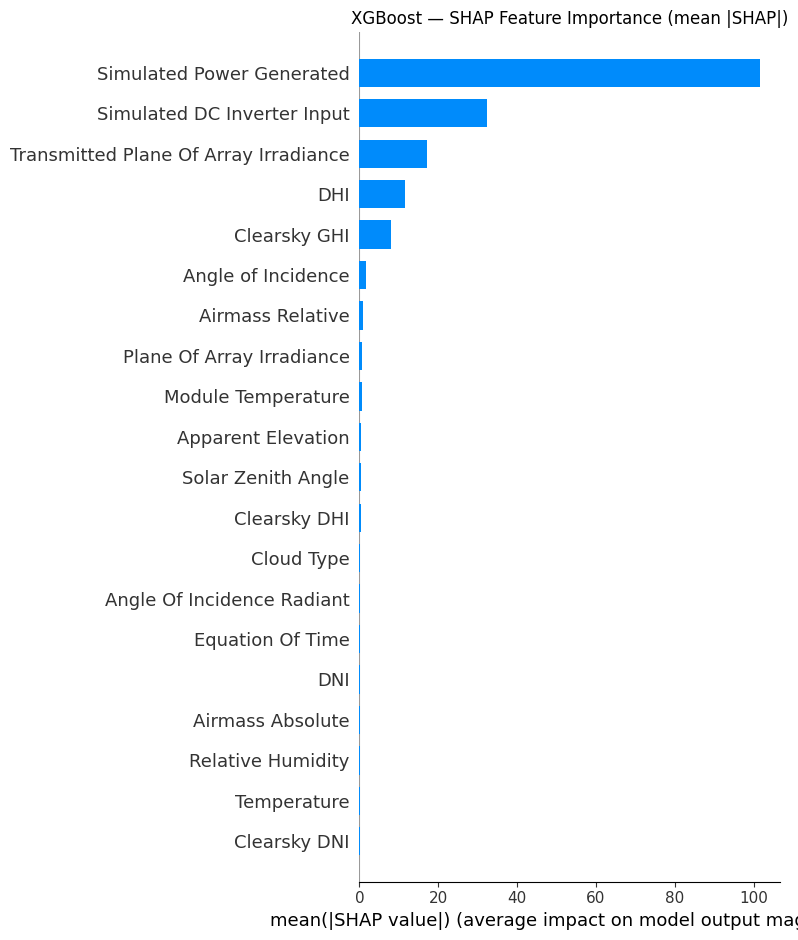

In [32]:
shap.summary_plot(xgb_shap_values, X_shap, plot_type='bar', show=False)
plt.title('XGBoost — SHAP Feature Importance (mean |SHAP|)')
plt.tight_layout()
plt.show()

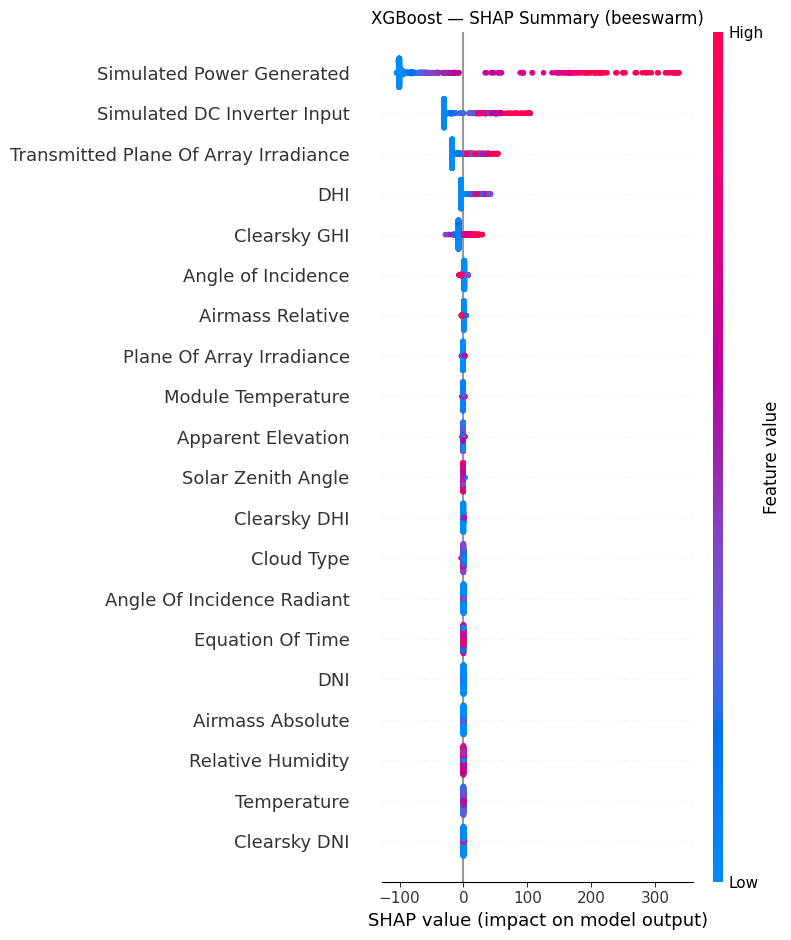

In [33]:
shap.summary_plot(xgb_shap_values, X_shap, show=False)
plt.title('XGBoost — SHAP Summary (beeswarm)')
plt.tight_layout()
plt.show()

In [34]:
# Combined importance ranking: RF impurity, XGB gain, RF |SHAP|, XGB |SHAP|
importance_table = pd.DataFrame({
    'RF_MDI':          rf_model.feature_importances_,
    'XGB_gain':        xgb_model.feature_importances_,
    'RF_mean_|SHAP|':  np.abs(rf_shap_values).mean(axis=0),
    'XGB_mean_|SHAP|': np.abs(xgb_shap_values).mean(axis=0),
}, index=X.columns)

# Average rank across the four metrics (1 = most important).
ranks = importance_table.rank(ascending=False)
importance_table['avg_rank'] = ranks.mean(axis=1)
importance_table = importance_table.sort_values('avg_rank')

importance_table.head(20)

,RF_MDI,XGB_gain,RF_mean_|SHAP|,XGB_mean_|SHAP|,avg_rank
Simulated Power Generated,0.446940,0.582807,62.536049,101.572121,1.50
Simulated DC Inverter Input,0.487157,0.298376,66.396989,32.237846,1.50
Transmitted Plane Of Array Irradiance,0.052081,0.085408,12.023340,17.065575,3.25
Clearsky GHI,0.008646,0.011113,11.545455,7.996226,4.50
DHI,0.004234,0.002677,15.121141,11.430202,5.00
Angle of Incidence,0.000123,0.004086,0.243514,1.704781,6.50
Plane Of Array Irradiance,0.000198,0.000245,0.459541,0.762457,8.50
Angle Of Incidence Radiant,0.000083,0.003803,0.191999,0.195932,9.25
Solar Zenith Angle,0.000032,0.000797,0.098655,0.448535,12.00
Airmass Relative,0.000029,0.001074,0.087557,0.934271,12.25
